In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
''' Setting up the libraries
%pip uninstall -y ydata-profiling pandas-profiling
%pip install -U fg-data-profiling
''' 

' Setting up the libraries\n%pip uninstall -y ydata-profiling pandas-profiling\n%pip install -U fg-data-profiling\n'

In [7]:
## df1 = pd.read_csv('train1.csv') - combined pdf's 

In [8]:
# df1

In [9]:
# df2 = pd.read_csv('train.csv')

In [10]:
# df2.head()

In [11]:
# combining both df's into single file
# df_train = pd.concat([df1,df2], ignore_index=True) 

In [12]:
# df_train.sample(10)

In [13]:
# df_train.head()

In [14]:
# Saving to CSV without the index column
# df_train.to_csv('train_set.csv', index=False)

In [15]:
#df_train.head()

In [16]:
df = pd.read_csv('train_set.csv')

In [17]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [18]:
df_train = pd.read_csv('train_set.csv')

In [19]:
df_train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [20]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [21]:
## !pip install pandas-profiling --> commenting this out coz pandas-profiling is outdated version

In [22]:
''' EDA checklist:
Q1. WHAT DO I HAVE?
    ☐ df.shape, df.dtypes, df.nunique()
    ☐ df.isnull().sum()  →  missing values?
    ☐ df.duplicated()    →  duplicates?
    ☐ df.describe()      →  ranges make sense?
    ☐ Classify each column: continuous / categorical / binary / ordinal
    DECISION → which columns need encoding, imputation, or removal

Q2. WHAT AM I PREDICTING?
    ☐ df['target'].value_counts()  →  class balance
    ☐ Compute dumb baseline score  →  floor to beat
    DECISION → need resampling? what metric to optimize?

Q3. WHAT DO FEATURES LOOK LIKE?
    ☐ Continuous → histograms, check skewness
    ☐ Categorical → value_counts, check for rare/dominant categories
    DECISION → need transforms (log)? any features nearly empty?

Q4. HOW DO FEATURES RELATE TO TARGET?  ← you started here ✓
    ☐ Correlation ranking (all features, one number each)
    ☐ Disease rate per category (for categoricals)
    ☐ Segregated means (for continuous)
    ☐ Overlaid histograms / bar charts
    DECISION → feature importance tiers, encoding strategy

Q5. HOW DO FEATURES RELATE TO EACH OTHER?
    ☐ Correlation matrix heatmap
    ☐ Flag pairs with |r| > 0.3
    DECISION → any redundant features? multicollinearity risk?
'''

" EDA checklist:\nQ1. WHAT DO I HAVE?\n    ☐ df.shape, df.dtypes, df.nunique()\n    ☐ df.isnull().sum()  →  missing values?\n    ☐ df.duplicated()    →  duplicates?\n    ☐ df.describe()      →  ranges make sense?\n    ☐ Classify each column: continuous / categorical / binary / ordinal\n    DECISION → which columns need encoding, imputation, or removal\n\nQ2. WHAT AM I PREDICTING?\n    ☐ df['target'].value_counts()  →  class balance\n    ☐ Compute dumb baseline score  →  floor to beat\n    DECISION → need resampling? what metric to optimize?\n\nQ3. WHAT DO FEATURES LOOK LIKE?\n    ☐ Continuous → histograms, check skewness\n    ☐ Categorical → value_counts, check for rare/dominant categories\n    DECISION → need transforms (log)? any features nearly empty?\n\nQ4. HOW DO FEATURES RELATE TO TARGET?  ← you started here ✓\n    ☐ Correlation ranking (all features, one number each)\n    ☐ Disease rate per category (for categoricals)\n    ☐ Segregated means (for continuous)\n    ☐ Overlaid hist

In [23]:
import sys
print(sys.executable)

C:\Users\ammar\anaconda3\python.exe


In [24]:
# from pandas_profiling import ProfileReport -- old version

# new version
# already imported: from data_profiling import ProfileReport

from data_profiling import ProfileReport
prof = ProfileReport(df_train, title='Training Data Report') # creating ProfileReport object
prof.to_file(output_file = 'train_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:03<00:00,  4.88it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [25]:
import os
os.path.exists("train_report.html") # True - so file has been created

True

In [26]:
# fixing the widget Error issue:
# %pip install -U ipywidgets jupyterlab_widgets widgetsnbextension

# ^^ above issue fixed

In [27]:
df_train.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')

In [28]:
df_train.sample(5)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
292915,292915,42,1,3,110,226,0,2,156,0,0.0,1,0,7,Absence
190954,190954,41,1,4,120,239,0,2,151,0,0.0,1,0,3,Absence
522019,522019,51,1,1,140,243,0,2,172,0,0.0,2,0,3,Absence
146190,146190,54,1,4,130,229,0,2,155,0,1.4,2,0,7,Absence
473404,473404,50,1,4,120,274,0,2,157,0,0.0,1,0,3,Absence


In [29]:
# converting Heart Disease to numeric:

# df_train['Heart Disease'] = df_train['Heart Disease'].map({'Absence':0, 'Presence': 1})

In [30]:
# df_train.sample(5)

In [31]:
# checking the target distribution: if the dataset is balanced or not

df_train['Heart Disease'].value_counts(normalize = True)

Heart Disease
Absence     0.55166
Presence    0.44834
Name: proportion, dtype: float64

In [32]:
''' Class balance check:
Absent = ~55%
Presence = ~45%

Dataset fairly balanced
'''

' Class balance check:\nAbsent = ~55%\nPresence = ~45%\n\nDataset fairly balanced\n'

In [33]:
''' based on my dataset, help understand which columns need transformations:

* chest pain type: has to be converted to one hot encoding coz type 4 has a much higher significance than types 1-3
* Thallium: needs one hot encoding coz values 3,6,7 dont mean anything as such, how to encode this
* Slope of ST: whats better One Hot encode or Ordinal
* EKG results: one hot encoding needed coz jump from 0/1 to 2 much significant than jump from 0 to 1
'''

' based on my dataset, help understand which columns need transformations:\n\n* chest pain type: has to be converted to one hot encoding coz type 4 has a much higher significance than types 1-3\n* Thallium: needs one hot encoding coz values 3,6,7 dont mean anything as such, how to encode this\n* Slope of ST: whats better One Hot encode or Ordinal\n* EKG results: one hot encoding needed coz jump from 0/1 to 2 much significant than jump from 0 to 1\n'

'''
# Splitting on basis of Impact:

# High Impact Ranking:
- 1: Thallium
- 2: Chest Pain Type
- 3: Max HR
- 4: Exercise Angina
- 5: Number of vessels during Fluroscopy
- 6: ST depression
- 7: Slope of ST wave

# Moderate Impact Ranking:
- 1: Sex
- 2: EKG results
- 3: Age

# Low Impact:
- 1: Cholesterol
- 2: FBS over 120
- 3: BP

'''

'''
# Significance of each column:
- ID: adds no meaning
- Age: elder patients at more risk of heart disease, moderate predictor = mod +ve corr
- Sex: males are more susceptible to heart disease, moderate impact predictor = mod +ve corr
- Chest Pain Type: strong predictor, type 4 holds greatest significance = strong +ve corr 
- BP: is long term risk factor but not a great diagnostic marker, weak predictor = weak -ve corr
- Cholesterol: alone doesnt say much, making it low impact. Split between LDL and HDL would add great value tho = weak +ve corr 
- FBS over 120: categorical - Fasting Blood Sugar - diabetes is risk factor but feature doesnt add much value = weak +ve corr
- EKG results: moderate predictor - needs One-Hot encoding = mod +ve corr
- Max HR: strong predictor - higher value indicates less risk = strong -ve corr
- Excersice angina: angina in controlled stress test - strong predictor = strong +ve corr
- ST depression: ST wave depression from EKG: strong predictor = strong +ve corr 
- Slope of ST: slope of ST wave - strong predictor = strong +ve corr
- Number of vessels Fluro - strong predictor = strong +ve corr
- Thallium: strongest predictor = strong +ve corr
'''

''' 
## Feature Transformation:
Starting with Chest Pain Type:

## Chest Pain Type:
- 1: Typical Angina
- 2: Atypical Angina
- 3: Non Anginal Pain
- 4: Asymptomatic

Clinicians classify chest pain by how many of these 3 criteria patient's symptoms meet:
- substernal location
- provoked by exertion or stress
- relieved by rest or nitroglycerin

- Typical angina meets all 3 
- Atypical angina meets 2 
- Non Angina: doesnt fit angina pattern - meets 0 or 1 criteria
- Asymptomatic: no chest pain reported at all

## what these mean:
- Typical = 1: strongest +ve signal for disease
- Atypical = 2: common in women, diabetics and elderly 
- Non Anginal = 3: at most 1 criteria, Pain sharp & positional
- Asymptomatic = 4: no chest pain, Patient referred for cardiac eval based on signals like abnormal ECG, risk factor profile - these patients are 3x more likely to be at risk
'''

In [37]:
# Distribution of Chest Pain across Absence-Presence:
df_train['Chest pain type'].value_counts()

Chest pain type
4    329179
3    197278
2     74941
1     28602
Name: count, dtype: int64

In [38]:
cp_count = df_train.groupby(['Chest pain type','Heart Disease']).size().unstack(fill_value=0)
cp_total_counts = cp_count.sum(axis=1)
cp_pct = cp_count.div(cp_total_counts, axis=0) * 100
display(cp_pct)

Heart Disease,Absence,Presence
Chest pain type,,
1,89.193063,10.806937
2,83.781908,16.218092
3,80.933505,19.066495
4,30.252234,69.747766


# Modeling insight:

This tells us that we need One Hot encoding -> types 1-3 in the 10-20% whereas type 4 jumps to 69%
Also aligns with what we discussed earlier about Chest Pain types - Type 4 is most predictive 

# Slope of ST:

This column captures the slope of ST wave in the ECG graph

Categorical feature:
1 - upsloping
2 - flat
3 - downsloping

Risk: Downsloping >> Flat > Upsloping

ST segment on the ECG shows how the heart recovers between beats during exercise

- Upsloping means the heart is recovering fine
- Flat and Downsloping indicate that the heart is not recovering or struggling to recover - indicative of high risk

In [41]:
# Slope of ST
df_train['Slope of ST'].value_counts()

Slope of ST
1    358293
2    256215
3     15492
Name: count, dtype: int64

In [42]:
slope_DCount = df_train.groupby(['Slope of ST', 'Heart Disease']).size().unstack(fill_value=0)
slope_total_counts = slope_DCount.sum(axis=1)
slope_disease_percentage = slope_DCount.div(slope_total_counts, axis=0) * 100
display(slope_disease_percentage)

Heart Disease,Absence,Presence
Slope of ST,,
1,73.774257,26.225743
2,30.793279,69.206721
3,27.891815,72.108185


## Insights:

- Major distinciton between 1 and 2 distribution percentages. Diff between type 2 and 3 not much
- Values 2 and 3 almost identical. The model will treat them very similarly
- Values 2 and 3 clinically very important - most patients who have either of these types in ST slope show Presence of Heart Disease
- Need to evaluate model performance properly coz only a small portion of the entire dataset shows this type 

# Thallium:

- This comes from the Thallium nuclear imaging stress test - Thallium absorption by the heart during stress test
- Healthy heart muscles absorb normally

Categorical:
3 - normal
6 - fixed defect
7 - reversible defect

- Fixed defect: area of the heart shows poor uptake indicating dead tissue
- Reversible defect: poor uptake during exercise but recovers at rest - indicative of hallmark ischemia => living tissue starved of blood during exertion

^^ Reversible defect is strong indicator of Heart Disease presence

In [45]:
# Thallium:
thal_cnts = df_train['Thallium'].value_counts()
display(thal_cnts)

Thallium
3    372286
7    246748
6     10966
Name: count, dtype: int64

In [46]:
thal_ttl = df_train['Thallium'].count()
display(thal_ttl)

630000

In [47]:
thal_pcts = thal_cnts.div(thal_ttl, axis=0) * 100
display(thal_pcts)

Thallium
3    59.093016
7    39.166349
6     1.740635
Name: count, dtype: float64

In [48]:
# distribution of Absence-Presence in Thallium types:

thal_count = df_train.groupby(['Thallium','Heart Disease']).size().unstack(fill_value=0) ## size gets rows per group, and unstack reshapes stacked list into readable table
print(thal_count)

Heart Disease  Absence  Presence
Thallium                        
3               298555     73731
6                 3439      7527
7                45552    201196


In [49]:
thal_ttl_counts = thal_count.sum(axis=1)
display(thal_ttl_counts)

Thallium
3    372286
6     10966
7    246748
dtype: int64

In [50]:
thal_pct = thal_count.div(thal_ttl_counts, axis=0) * 100
display(thal_pct)

Heart Disease,Absence,Presence
Thallium,,
3,80.195065,19.804935
6,31.360569,68.639431
7,18.460940,81.539060


## Modeling insight:
- Thallium is strongest single predictor
- Values 3,6,7 have no numeric relation so need to One Hot encode
- value 6 is a very low % of the distribution so need to need to be careful in modeling

# EKG Results:

Categorical:
- 0 - normal
- 1 - ST-T wave abnormality (T wave inversions or ST elevation/depression > 0.05 mV)
- 2 - Definite Left Ventricular Hypertrophy by Estes Criteria

In [53]:
# distribution of Absence-Presence in EKG results:

df_train['EKG results'].value_counts()

EKG results
0    320116
2    308562
1      1322
Name: count, dtype: int64

In [54]:
ekg_counts = df_train.groupby(['EKG results','Heart Disease']).size().unstack(fill_value=0)
display(ekg_counts)

Heart Disease,Absence,Presence
EKG results,,
0,210797,109319
1,846,476
2,135903,172659


In [55]:
ekg_ttl_counts = ekg_counts.sum(axis=1)
display(ekg_ttl_counts)

EKG results
0    320116
1      1322
2    308562
dtype: int64

In [56]:
ekg_pct = ekg_counts.div(ekg_ttl_counts, axis=0) * 100
display(ekg_pct)

Heart Disease,Absence,Presence
EKG results,,
0,65.850192,34.149808
1,63.993949,36.006051
2,44.043985,55.956015


## Modeling insights:

- EKG results is weaker than any other categorical feature: total spread from o to 2 is just 20 % points, whereas Thallium (62pp), Chest Pain (59pp), and Slope of ST(46pp)
- Value 1 almost no existential - so model barely has anything to learn about this category
- One Hot Encode to keep with consistency

# Feature Transformation: One Hot Encoding categorical features

- Thallium
- Chest Pain Type
- Slope of ST
- EKG results

In [59]:
## need to One Hot Encode Chest Pain type as jump from 1 to 3 not as severe as jump from 1 to 4

df_train = pd.get_dummies(df_train, 
    columns=['Chest pain type', 'Thallium', 'Slope of ST', 'EKG results'],
    prefix=['cptype', 'thal', 'slopeST', 'ekg'])

In [60]:
df_train.head(10)

,id,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Number of vessels fluro,...,cptype_4,thal_3,thal_6,thal_7,slopeST_1,slopeST_2,slopeST_3,ekg_0,ekg_1,ekg_2
0,0,58,1,152,239,0,158,1,3.6,2,...,True,False,False,True,False,True,False,True,False,False
1,1,52,1,125,325,0,171,0,0.0,0,...,False,True,False,False,True,False,False,False,False,True
2,2,56,0,160,188,0,151,0,0.0,0,...,False,True,False,False,True,False,False,False,False,True
3,3,44,0,134,229,0,150,0,1.0,0,...,False,True,False,False,False,True,False,False,False,True
4,4,58,1,140,234,0,125,1,3.8,3,...,True,True,False,False,False,True,False,False,False,True
5,5,38,1,138,283,0,147,1,1.6,2,...,True,False,False,True,False,True,False,True,False,False
6,6,59,1,130,246,0,152,0,0.8,2,...,True,True,False,False,False,True,False,False,False,True
7,7,60,0,120,245,0,151,0,1.2,0,...,False,True,False,False,True,False,False,True,False,False
8,8,48,0,140,212,0,125,0,0.0,0,...,True,True,False,False,True,False,False,False,False,True
9,9,44,0,150,197,0,150,0,0.0,0,...,True,True,False,False,False,True,False,True,False,False


In [61]:
df_train.columns

Index(['id', 'Age', 'Sex', 'BP', 'Cholesterol', 'FBS over 120', 'Max HR',
       'Exercise angina', 'ST depression', 'Number of vessels fluro',
       'Heart Disease', 'cptype_1', 'cptype_2', 'cptype_3', 'cptype_4',
       'thal_3', 'thal_6', 'thal_7', 'slopeST_1', 'slopeST_2', 'slopeST_3',
       'ekg_0', 'ekg_1', 'ekg_2'],
      dtype='object')

In [62]:
df_train['Heart Disease'].value_counts()

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

In [63]:
## converting Heart Disease into Binary:

df_train['Heart Disease'] = df_train['Heart Disease'].map({'Absence':0, 'Presence': 1})

In [64]:
df_train['Heart Disease'].value_counts()

Heart Disease
0    347546
1    282454
Name: count, dtype: int64

# Handling continuous features: Age, Max HR, ST depression, BP, Cholesterol

## Need to understand:
- what each feature's distribution looks like
- its predictive power in relation to Heart Disease

In [66]:
df_train[['Age','Max HR','ST depression','BP','Cholesterol']].describe()

,Age,Max HR,ST depression,BP,Cholesterol
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,54.136706,152.816763,0.716028,130.497433,245.011814
std,8.256301,19.112927,0.948472,14.975802,33.681581
min,29.000000,71.000000,0.000000,94.000000,126.000000
25%,48.000000,142.000000,0.000000,120.000000,223.000000
50%,54.000000,157.000000,0.100000,130.000000,243.000000
75%,60.000000,166.000000,1.400000,140.000000,269.000000
max,77.000000,202.000000,6.200000,200.000000,564.000000


In [67]:
sns.histplot(data=df_train, x='Age', bins=20, kde=True)

<Axes: xlabel='Age', ylabel='Count'>

# Age:
- data is normally distributed
- no skewness

In [69]:
# Max HR:

sns.histplot(data=df_train, x='Max HR', bins=20, kde=True)

<Axes: xlabel='Age', ylabel='Count'>

# Max HR:
- slightly left skewed

In [71]:
# ST Depression:

sns.histplot(data=df_train, x='ST depression', bins=20, kde=True)

<Axes: xlabel='Age', ylabel='Count'>

# ST Depression:
- Heavily right skewed data
- Most patients have little to no depression, but few have values as large as 6.2 pulling the mean up
- need to perform log transform: log(1+x) to compress the long right tail

In [73]:
# BP:

sns.histplot(data=df_train, x='BP', bins=20, kde=True)

<Axes: xlabel='Age', ylabel='Count'>

# BP:
- Mean is at clinical bordeline
-- Normal: BP < 120
-- Elevated: 120-129
-- High: 130+

- not a strong predictor of disease so doesnt hold much predictive power

In [75]:
# Cholesterol:

sns.histplot(data=df_train, x = 'Cholesterol', bins=20, kde=True)

<Axes: xlabel='Age', ylabel='Count'>

# Cholesterol:
- Max = 564 
- has some extreme outliers
- this is a weak predictor, so outliers wont matter much

# Correlation of Continuous variables with the Target

In [78]:
df_train[['Age', 'Max HR', 'ST depression', 'BP', 'Cholesterol']].corrwith(df_train['Heart Disease'])

Age              0.212091
Max HR          -0.440985
ST depression    0.430641
BP              -0.005181
Cholesterol      0.082753
dtype: float64

# These correlation numbers help see which variables hold predictive power
Variables in rank of Predictive power:
- ST depression: strong +ve correlation -> More prob of disease
- Max HR: strong -ve correlation -> Less prob of disease
- Age: moderate +ve correlation -> More prob of disease
- Cholesterol: weak +ve corr -> doesnt matter
- BP: weak -ve corr -> noise

# Overlaid Histograms to see class split:
- The more separation we see in Histograms the more useful the feature is

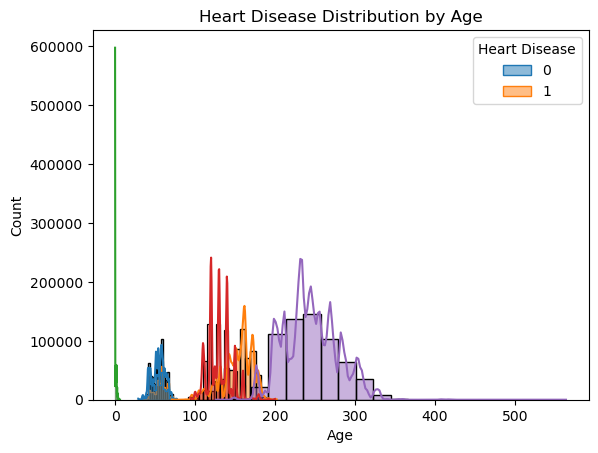

In [81]:
# Overlaid Histogram for Heart Disease - Age

%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df_train, x='Age', hue='Heart Disease', bins=20, alpha=0.5, element="step")

plt.title('Heart Disease Distribution by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Age has good separation - good indicator

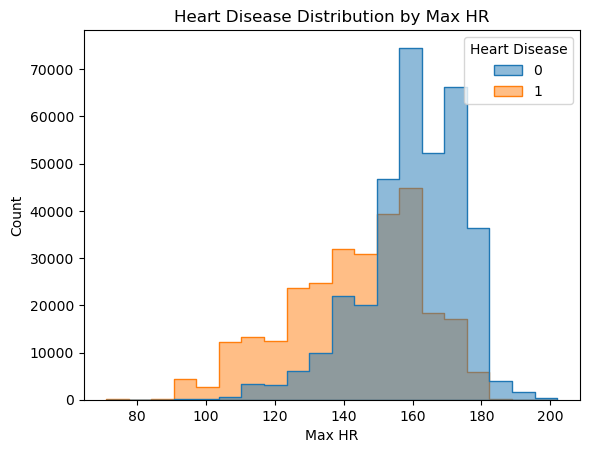

In [83]:
# Overlaid Histogram for Heart Disease - Max HR
sns.histplot(data=df_train, x='Max HR', hue='Heart Disease', bins=20, alpha=0.5, element='step')
plt.title('Heart Disease Distribution by Max HR')
plt.show()

# Max HR has clear separation - strong indicator

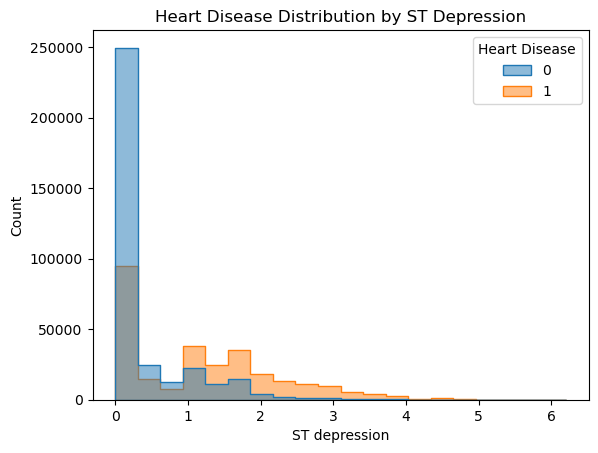

In [85]:
# Histogram for Heart Disease - ST depression
sns.histplot(data=df_train, x='ST depression', hue='Heart Disease', bins=20, alpha=0.5, element='step')
plt.title('Heart Disease Distribution by ST Depression')
plt.show()

# ST depression has clear separation - very strong indicator

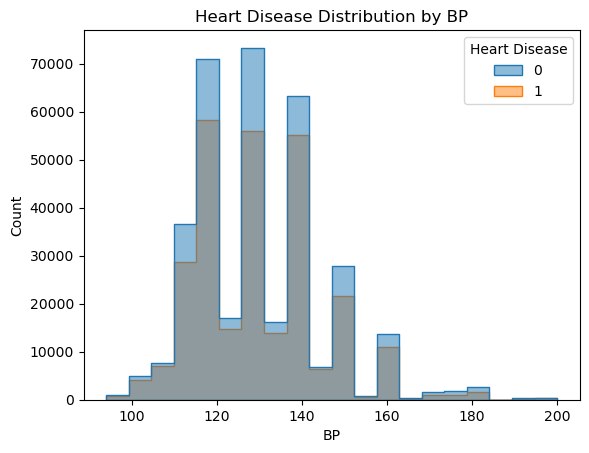

In [87]:
# Histogram for Heart Disease - BP:
sns.histplot(data=df_train, x='BP', hue='Heart Disease', bins=20, alpha=0.5, element='step')
plt.title('Heart Disease Distribution by BP')
plt.show()

# BP has clear overlap - so weak indicator

<Axes: xlabel='Cholesterol', ylabel='Count'>

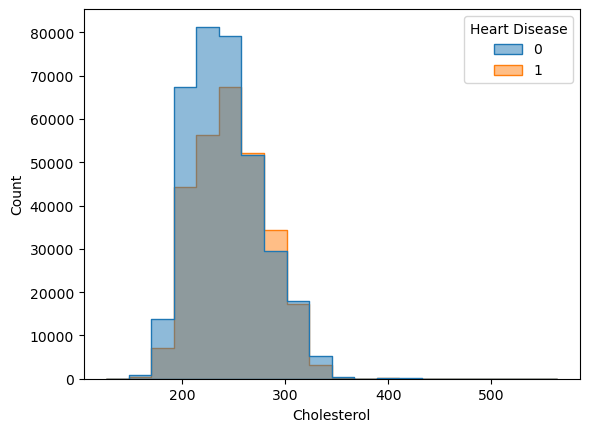

In [89]:
# Cholesterol - Heart Disease:
sns.histplot(data=df_train, x='Cholesterol', hue='Heart Disease', bins=20, alpha=0.5, element='step')

# Cholesterol has clear overlap - weak indicator

# Now plotting Heatmap - to see feature-to-feature correlation
-- will indicate if any features are redundant with each other

In [92]:
df_train.head()

,id,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Number of vessels fluro,...,cptype_4,thal_3,thal_6,thal_7,slopeST_1,slopeST_2,slopeST_3,ekg_0,ekg_1,ekg_2
0,0,58,1,152,239,0,158,1,3.6,2,...,True,False,False,True,False,True,False,True,False,False
1,1,52,1,125,325,0,171,0,0.0,0,...,False,True,False,False,True,False,False,False,False,True
2,2,56,0,160,188,0,151,0,0.0,0,...,False,True,False,False,True,False,False,False,False,True
3,3,44,0,134,229,0,150,0,1.0,0,...,False,True,False,False,False,True,False,False,False,True
4,4,58,1,140,234,0,125,1,3.8,3,...,True,True,False,False,False,True,False,False,False,True


In [93]:
df_train.columns

Index(['id', 'Age', 'Sex', 'BP', 'Cholesterol', 'FBS over 120', 'Max HR',
       'Exercise angina', 'ST depression', 'Number of vessels fluro',
       'Heart Disease', 'cptype_1', 'cptype_2', 'cptype_3', 'cptype_4',
       'thal_3', 'thal_6', 'thal_7', 'slopeST_1', 'slopeST_2', 'slopeST_3',
       'ekg_0', 'ekg_1', 'ekg_2'],
      dtype='object')

In [94]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [95]:
df.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')

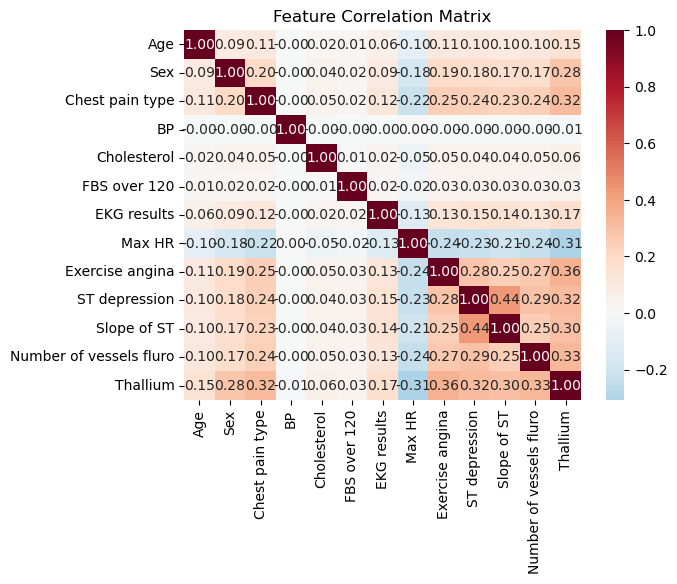

In [96]:
# selecting features
features = ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

# plot heatmap
sns.heatmap(df[features].corr(), annot=True,fmt='.2f', cmap='RdBu_r', center=0)

plt.title('Feature Correlation Matrix')
#plt.tight_layout()
plt.show()

In [97]:
# Correlation numbers:
df_corr = df[features].corr()

In [98]:
df_corr

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
Age,1.000000,0.088397,0.109453,-0.003960,0.019485,0.013354,0.057431,-0.097542,0.110153,0.103064,0.096337,0.102758,0.150124
Sex,0.088397,1.000000,0.195893,-0.003355,0.038373,0.020333,0.093590,-0.176186,0.192705,0.181093,0.169854,0.174700,0.275282
Chest pain type,0.109453,0.195893,1.000000,-0.003587,0.045463,0.023036,0.120907,-0.221806,0.246211,0.240228,0.233849,0.236787,0.319887
BP,-0.003960,-0.003355,-0.003587,1.000000,-0.004597,-0.000784,-0.003738,0.004391,-0.003295,-0.004024,-0.003203,-0.003143,-0.005884
Cholesterol,0.019485,0.038373,0.045463,-0.004597,1.000000,0.006212,0.024948,-0.048575,0.049774,0.044678,0.040197,0.048800,0.061817
FBS over 120,0.013354,0.020333,0.023036,-0.000784,0.006212,1.000000,0.016258,-0.024895,0.027971,0.031324,0.030327,0.025691,0.032895
EKG results,0.057431,0.093590,0.120907,-0.003738,0.024948,0.016258,1.000000,-0.125047,0.128814,0.149273,0.144468,0.130943,0.169017
Max HR,-0.097542,-0.176186,-0.221806,0.004391,-0.048575,-0.024895,-0.125047,1.000000,-0.236232,-0.229462,-0.206190,-0.236319,-0.306912
Exercise angina,0.110153,0.192705,0.246211,-0.003295,0.049774,0.027971,0.128814,-0.236232,1.000000,0.281298,0.245243,0.270413,0.357076
ST depression,0.103064,0.181093,0.240228,-0.004024,0.044678,0.031324,0.149273,-0.229462,0.281298,1.000000,0.438240,0.293642,0.316891


In [99]:
# highlight values >0.3

# function to style the cells
def highlight_strong_corr(val):
    # Ignore perfect correlations of 1.0
    if val == 1.0:
        return ''
    
    # Highlight strong positive or negative correlations
    elif val > 0.3 or val < -0.3:
        return 'background-color: #FFFF00; color: black; font-weight: bold;'
    return ''

# apply the style and display
df_corr.style.map(highlight_strong_corr)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
Age,1.000000,0.088397,0.109453,-0.003960,0.019485,0.013354,0.057431,-0.097542,0.110153,0.103064,0.096337,0.102758,0.150124
Sex,0.088397,1.000000,0.195893,-0.003355,0.038373,0.020333,0.093590,-0.176186,0.192705,0.181093,0.169854,0.174700,0.275282
Chest pain type,0.109453,0.195893,1.000000,-0.003587,0.045463,0.023036,0.120907,-0.221806,0.246211,0.240228,0.233849,0.236787,0.319887
BP,-0.003960,-0.003355,-0.003587,1.000000,-0.004597,-0.000784,-0.003738,0.004391,-0.003295,-0.004024,-0.003203,-0.003143,-0.005884
Cholesterol,0.019485,0.038373,0.045463,-0.004597,1.000000,0.006212,0.024948,-0.048575,0.049774,0.044678,0.040197,0.048800,0.061817
FBS over 120,0.013354,0.020333,0.023036,-0.000784,0.006212,1.000000,0.016258,-0.024895,0.027971,0.031324,0.030327,0.025691,0.032895
EKG results,0.057431,0.093590,0.120907,-0.003738,0.024948,0.016258,1.000000,-0.125047,0.128814,0.149273,0.144468,0.130943,0.169017
Max HR,-0.097542,-0.176186,-0.221806,0.004391,-0.048575,-0.024895,-0.125047,1.000000,-0.236232,-0.229462,-0.206190,-0.236319,-0.306912
Exercise angina,0.110153,0.192705,0.246211,-0.003295,0.049774,0.027971,0.128814,-0.236232,1.000000,0.281298,0.245243,0.270413,0.357076
ST depression,0.103064,0.181093,0.240228,-0.004024,0.044678,0.031324,0.149273,-0.229462,0.281298,1.000000,0.438240,0.293642,0.316891


# Insight:

- two highly correlated features are essentially giving us the same signal
- in linear models correlated features can make coefficient estimates unstable and the model wont know which one to credit 
- in our problem: applying domain knowledge: ST depression and Slope of ST both measure the same phenomenon of the EKG result, these arent two independent signals

# Features and why they correlate:

- ST Depression - Slope of ST: r=0.44 -> both measure the same EKG phenomenon during exercise
- Thallium - Exercise Angina: r=0.35 -> both capture stress-test pathology
- Thallium - Chest pain type: r=0.32 -> chest pain severity tracks with test results
- Thallium - ST depression: r=0.32 -> EKG changes track with perfusion defects
- Thallium - No of vessels: r=0.33 -> both measure structural heart damage
- Thallium - Max HR: r=-0.31 -> damaged hearts cant reach high HR

## Thallium has correlation with 5 other features - making it the most important signal / most direct diagnostic test

## Modeling insight: no feature has correlation > 0.5 - so no need to drop any features

# Preprocessing and Building the Baseline Model

In [103]:
df_train.columns

Index(['id', 'Age', 'Sex', 'BP', 'Cholesterol', 'FBS over 120', 'Max HR',
       'Exercise angina', 'ST depression', 'Number of vessels fluro',
       'Heart Disease', 'cptype_1', 'cptype_2', 'cptype_3', 'cptype_4',
       'thal_3', 'thal_6', 'thal_7', 'slopeST_1', 'slopeST_2', 'slopeST_3',
       'ekg_0', 'ekg_1', 'ekg_2'],
      dtype='object')

# Feature Encoding:
## One Hot encoding for features:
- Chest Pain Type
- Thallium
- Slope of ST
- EKG Results

^^ This is done

## Continuous features:
- Max HR
- ST depression
- Age
- BP
- Cholesterol

^^ keeping as is

## Binary features:
- Sex
- FBS over 120
- Exercise Angina

^^ keeping as is

## Ordinal features:
- Number of vessels fluro

^^ keeping as is

In [108]:
## Features from train that have to be dropped:
drop_features = ['id','Heart Disease']

In [109]:
# continuous features:
cont_feat = ['Max HR','ST depression','Age','BP','Cholesterol']

df_train[cont_feat].head()

,Max HR,ST depression,Age,BP,Cholesterol
0,158,3.6,58,152,239
1,171,0.0,52,125,325
2,151,0.0,56,160,188
3,150,1.0,44,134,229
4,125,3.8,58,140,234


## these features need Scaling as they're in very different scales - i.e. ST Depression in units, Cholesterol in Hundreds
## features being in different scales for Linear Models will lead to one feature gaining dominance in predictive power over a feature in a smaller scale

In [111]:
# Scaling these continuous features:
## Training:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # creating StandardScaler object

# fitting scaler object on train data
df_train[cont_feat] = scaler.fit_transform(df_train[cont_feat]) ## fit_transform here learns the mean/std and scales

In [112]:
df_train[cont_feat].head() ## scaling complete

,Max HR,ST depression,Age,BP,Cholesterol
0,0.271190,3.040655,0.467921,1.435822,-0.178490
1,0.951359,-0.754928,-0.258797,-0.367088,2.374837
2,-0.095054,-0.754928,0.225682,1.970017,-1.692672
3,-0.147375,0.299400,-1.227755,0.233882,-0.475388
4,-1.455391,3.251520,0.467921,0.634529,-0.326939


In [113]:
df_train.columns

Index(['id', 'Age', 'Sex', 'BP', 'Cholesterol', 'FBS over 120', 'Max HR',
       'Exercise angina', 'ST depression', 'Number of vessels fluro',
       'Heart Disease', 'cptype_1', 'cptype_2', 'cptype_3', 'cptype_4',
       'thal_3', 'thal_6', 'thal_7', 'slopeST_1', 'slopeST_2', 'slopeST_3',
       'ekg_0', 'ekg_1', 'ekg_2'],
      dtype='object')

In [114]:
## selecting feature columns: need all columns except ID and Heart Disease

feat_cols = [c for c in df_train.columns if c not in drop_features]
feat_cols

['Age',
 'Sex',
 'BP',
 'Cholesterol',
 'FBS over 120',
 'Max HR',
 'Exercise angina',
 'ST depression',
 'Number of vessels fluro',
 'cptype_1',
 'cptype_2',
 'cptype_3',
 'cptype_4',
 'thal_3',
 'thal_6',
 'thal_7',
 'slopeST_1',
 'slopeST_2',
 'slopeST_3',
 'ekg_0',
 'ekg_1',
 'ekg_2']

In [115]:
## Now extracing X and y for modeling:

df_train[feat_cols] = df_train[feat_cols].astype(float)
X = df_train[feat_cols].values
y = df_train['Heart Disease'].values

In [116]:
X.shape # feature matrix

(630000, 22)

In [117]:
y.shape # target array

(630000,)

# ^^ Feature Preprocessing complete

# Building baseline model: 

- Opting for Logistic Regression coz the challenge asks for probabilities of Heart Disease for each ID
- Logistic Regression outputs P(disease) through the sigmoid function: S(x) = 1 / (1 + e^-x)

## Opting for 5 fold cross validation coz we need a reliable score
- in a 80/20 train-test split the score depends on which rows got selected in train and test. It'll be hard to tell if score improvement came from real model change of just a lucky split

- Cross validation solves for this by testing on every row once across 5 different splits, then averaging
- this also gives a stable mean, and the SD tells how much natural variance exists
- also using random_state = 42 to repeat results

# Steps:
- 1 - Preprocess
- 2 - Train
- 3 - Predict
- 4 - Main
- 5 - Dockerfile
- 6 - Requirements

In [121]:
df_train.head()

,id,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Number of vessels fluro,...,cptype_4,thal_3,thal_6,thal_7,slopeST_1,slopeST_2,slopeST_3,ekg_0,ekg_1,ekg_2
0,0,0.467921,1.0,1.435822,-0.178490,0.0,0.271190,1.0,3.040655,2.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
1,1,-0.258797,1.0,-0.367088,2.374837,0.0,0.951359,0.0,-0.754928,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,2,0.225682,0.0,1.970017,-1.692672,0.0,-0.095054,0.0,-0.754928,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,3,-1.227755,0.0,0.233882,-0.475388,0.0,-0.147375,0.0,0.299400,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,4,0.467921,1.0,0.634529,-0.326939,0.0,-1.455391,1.0,3.251520,3.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [122]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  float64
 2   Sex                      630000 non-null  float64
 3   BP                       630000 non-null  float64
 4   Cholesterol              630000 non-null  float64
 5   FBS over 120             630000 non-null  float64
 6   Max HR                   630000 non-null  float64
 7   Exercise angina          630000 non-null  float64
 8   ST depression            630000 non-null  float64
 9   Number of vessels fluro  630000 non-null  float64
 10  Heart Disease            630000 non-null  int64  
 11  cptype_1                 630000 non-null  float64
 12  cptype_2                 630000 non-null  float64
 13  cptype_3                 630000 non-null  float64
 14  cpty

# The scoring metrics:

- Using AUC-ROC as primary metric - this gives a measure of how well our model ranks patients (sick ones get higher probs than healthy ones)
- Log-loss: will penalize confident wrong predictions

In [124]:
#1 : Cross Validation with AUC-ROC and Log-Loss:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

model_lr = LogisticRegression(max_iter=1000, random_state = 42) # creating LR object

In [125]:
# finding primary metric : AUC-ROC

auc_scores = cross_val_score(model_lr, X, y, cv=5, scoring = 'roc_auc')
print(f"AUC-ROC:  {auc_scores.mean():.4f} +/- {auc_scores.std():.4f}")

AUC-ROC:  0.9527 +/- 0.0005


# AUC-ROC score = 0.9527 +/- 0.0005

In [127]:
# Secondary metric: Log-Loss (sklearn returns negative so negate)

logloss_scores = cross_val_score(model_lr, X, y, cv=5, scoring='neg_log_loss')
print(f"Log-Loss: {-logloss_scores.mean():.4f} +/- {logloss_scores.std():.4f}")

Log-Loss: 0.2759 +/- 0.0015


# Log-Loss: 0.2759 +/- 0.0015

In [129]:
# accuracy too

acc_scores = cross_val_score(model_lr, X, y, cv=5, scoring='accuracy')
print(f"Accuracy: {acc_scores.mean():.4f} +/- {acc_scores.std():.4f}")

Accuracy: 0.8853 +/- 0.0006


# Accuracy: 0.8853 +/- 0.0006

# Inspecting co-efficients:

In [132]:
# fitting on training data to inspect coefficients
model_lr.fit(X, y)

coef_df = pd.DataFrame({
    'Feature': feat_cols,
    'Coefficient': model_lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))

                Feature  Coefficient
                 thal_3    -1.385241
               cptype_4     1.237879
        Exercise angina     1.195248
                    Sex     1.054595
               cptype_1    -1.010755
Number of vessels fluro     0.868254
              slopeST_1    -0.855439
                 Max HR    -0.835231
                 thal_7     0.573715
                  ekg_0    -0.545616
               cptype_2    -0.537275
          ST depression     0.445218
               cptype_3    -0.433050
                    Age     0.349101
                  ekg_2    -0.116874
            Cholesterol     0.095810
                  ekg_1    -0.080711
                 thal_6     0.068325
              slopeST_3     0.057707
              slopeST_2     0.054532
           FBS over 120    -0.046417
                     BP     0.004941


# Visualizing coefficient magnitudes:

C:\Users\ammar\AppData\Local\Temp\ipykernel_42660\1748429569.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature',


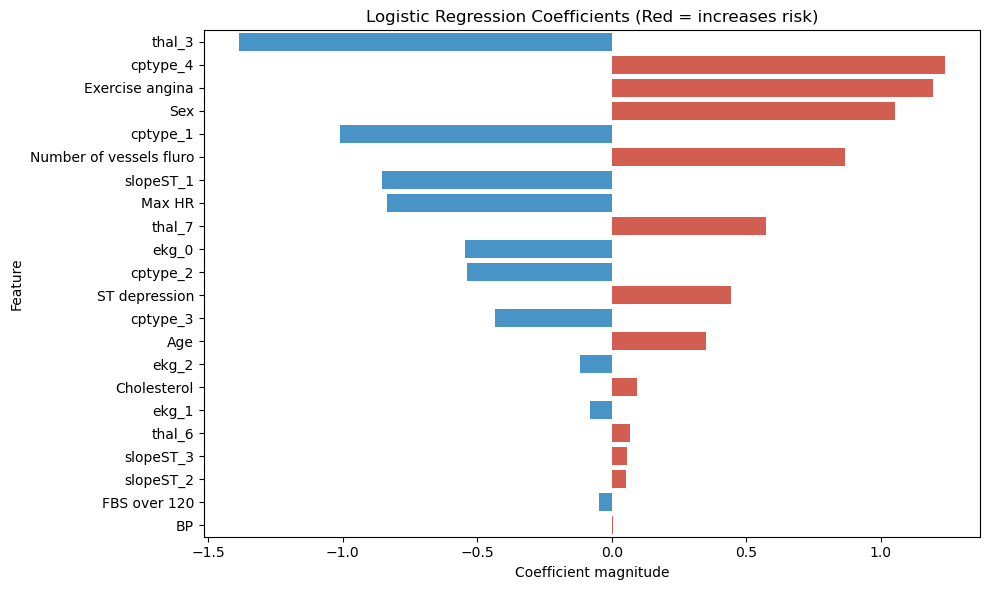

In [134]:
plt.figure(figsize=(10, 6)) # defining fig size
sns.barplot(data=coef_df, x='Coefficient', y='Feature', 
            palette=['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]) # barplot that shows magnitude of coefficients in coef_df - Blue is coef is -ve and Red if coef is +ve
plt.title('Logistic Regression Coefficients (Red = increases risk)')
plt.xlabel('Coefficient magnitude')
plt.tight_layout()
plt.show()

# What the results say:

- AUC-ROC > 0.85: good baseline, preprocessing clean
- Std Dev < 0.01: no data leakages
- thal_7, cptype_4 have large +ve coeff: this conforms with our healthcare domain knowledge
- thal_3, slopeST_1 have large -ve coeff: aligns with healthcare understanding - patients with these features less likely to have disease
- BP, Cholesterol, FBS > 120 almost zero: aligns with EDA showing them as weak predictors
- Sex ranked +1.05 which is 4th largest coefficient. Shows that after controlling for all other features, being male is still a strong independent risk factor

# Now trying Random Forest:

- To see if there is signal in feature interactions and to find any non-linear patterns that LR missed
- doing this coz Random Forest captures non-linear patterns like - Age > 60 AND Thallium=7 is way riskier than either of these features alone
- RF discovers feature interactions through its branching and handles curved boundaries naturally

## Key hyperparameters:
- n_estimators : this is the number of trees. We want enough to get a stable model but not so many it takes forever to train the model
- max_depth : this limits how deep each tree grows, helps prevent overfitting to noise
- min_samples_leaf : number of patients each leaf needs, helps prvent memorizing individual rows
- random_state : for reproducibility of results  

In [227]:
from sklearn.ensemble import RandomForestClassifier

# creating RF object
model_rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth = 10,
    min_samples_leaf = 50,
    random_state = 42,
    n_jobs = -1 # this will use all my CPU cores
) 

# AUC-ROC
rf_auc = cross_val_score(model_rf, X, y, cv=5, scoring='roc_auc')
print(f"RF AUC-ROC:  {rf_auc.mean():.4f} +/- {rf_auc.std():.4f}")
print(f"LR AUC-ROC:  {auc_scores.mean():.4f} (baseline)")
print(f"Improvement: {rf_auc.mean() - auc_scores.mean():.4f}")

RF AUC-ROC:  0.9507 +/- 0.0005
LR AUC-ROC:  0.9527 (baseline)
Improvement: -0.0020


# Inspecting feature importances:

In [230]:
model_rf.fit(X, y)

rf_importance = pd.DataFrame({
    'Feature': feat_cols,
    'Importance': model_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(rf_importance.to_string(index=False))

                Feature  Importance
                 thal_3    0.211119
                 thal_7    0.169341
               cptype_4    0.153384
Number of vessels fluro    0.097957
                 Max HR    0.077674
        Exercise angina    0.069986
              slopeST_1    0.065416
          ST depression    0.047994
              slopeST_2    0.029230
                    Sex    0.025510
               cptype_3    0.020694
                    Age    0.009810
               cptype_2    0.006810
                  ekg_2    0.005564
                  ekg_0    0.003681
               cptype_1    0.002326
            Cholesterol    0.001300
                 thal_6    0.001245
              slopeST_3    0.000498
                     BP    0.000420
           FBS over 120    0.000042
                  ekg_1    0.000002


# Interpretation from RF model:

## Is RF scoring lower than LR bad?
This lower score for RF tells us that the relationship between our features and heart disease is predominantly linear. LR's straight line decision boundary was already capturing nearly all the signal. Also suggests that there arent any major hidden interactions that RF could exploit

## Is this common?

Yes, this happens when:
- data is well-structured with pre-engineered features (preprocessing we did)
- features were encoded meaningfully (one-hot encoding we followed)
- dataset is large and clean with no missing values and has balanced classes

RF and Tree-based models dominate for messy real world data with raw text, images and variuous noisy features. LR holds good on curated tabular clinical data

## Why RF scored bad?
With max_depth=10 and min_samples_leaf=50 we constrained the trees to prevent overfitting. This in-turn limited RFs ability to fit the data as tightly as LR. But this is also the right tradeoff to make coz an overfit RF scoring 0.96 on train data but 0.93 on new data is worse

# Feature Importance:
Top and bottom features are similar across both LR and RF with little shuffling in the middle. Reason being LR measures linear contribution while RF measures how useful each feature is for splitting decision trees

## Key insight: 
Sex moved from 4th in LR to 10th in RF, suggesting that Sex's predictive power is mostly linear (males has a higher risk) rather than interacting with other features



# Now trying XGBoost:

Unlike RF, XGBoost works by building trees sequentially where each new tree fixes mistakes of the previous tree, that is:
- Tree 1 makes predictions -> some patients classified wrong
- Tree 2 trained only on errors of Tree 1 -> fixes some mistakes
- this process continues for multiple rounds where each tree corrects mistakes of the one before

## Why we're trying XGB after RF?
- In RF all trees have equal vote and RF is good at capturing general patterns
- In XGB, later trees are weighted by how much they improve and its an overall better model at capturing hard to classify cases which RF and LR might have got wrong

Caution: XGB is also more prone to overfitting as its trees get trained on the errors of the previous tree, so make sure the `std dev` stays low, else the model would just be memorizing noise

# Key Hyperparameters:
- n_estimators : number of boosting rounds
- max_depth : we keep a shallower depth than RF coz boosting compounds dpeth across trees -> deep trees overfit fast
- learning_rate : how much each tree contributes -> smaller more conservative values gives less overfitting
- min_child_weight : similar to min_samples_leaf -> prevents chasing tiny group of patients
- subsample : % of rows each tree sees -> adds randomness to prevent overfitting
- colsample_bytree : % of features each tree sees
- eval_metric : using logloss here to align with challenge goal

In [234]:
# installing xgboost:
%pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 435.7 kB/s eta 0:03:54
   ---------------------------------------- 0.1/101.7 MB 871.5 kB/s eta 0:01:57
   ---------------------------------------- 0.3/101.7 MB 2.6 MB/s eta 0:00:39
    --------------------------------------- 1.5/101.7 MB 7.7 MB/s eta 0:00:13
   - -------------------------------------- 2.9/101.7 MB 12.1 MB/s eta 0:00:09
   - -------------------------------------- 4.4/101.7 MB 15.5 MB/s eta 0:00:07
   -- ------------------------------------- 6.1/101.7 MB 18.6 MB/s eta 0:00:06
   --- ------------------------------------ 8.4/101.7 MB 22.5 MB/s eta 0:00:05
   --- ------------------------------------ 10.1/101.7 MB 23.9 MB/s eta 0:00:04
   --- ------------------------------------ 10.1/101.7 MB 23.1 MB/s eta 0:00:04
   --- ------------------------------------ 10.1/101.7 MB 23.1 MB/s eta 0:00:04
   ---- ----------------------------------- 11.8/101.7 M

In [236]:
# modeling:

from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators = 300,
    max_depth = 5,
    learning_rate = 0.1,
    min_child_weight = 50,
    subsample = 0.8,
    colsample_bytree = 0.8,
    eval_metric = 'logloss',
    random_state = 42,
    n_jobs = -1)

# AUC-ROC:
xgb_auc = cross_val_score(model_xgb, X, y, cv=5, scoring = 'roc_auc')

print(f"XGB AUC-ROC: {xgb_auc.mean():.4f} +/- {xgb_auc.std():.4f}")
print(f"RF AUC-ROC: {rf_auc.mean():.4f}")
print(f"LR AUC-ROC: {auc_scores.mean():.4f} (baseline)")
print(f"Improvement over LR: {xgb_auc.mean() - auc_scores.mean():.4f}")

XGB AUC-ROC: 0.9552 +/- 0.0004
RF AUC-ROC: 0.9507
LR AUC-ROC: 0.9527 (baseline)
Improvement over LR: 0.0025


# Feature Importance:

In [239]:
model_xgb.fit(X, y)

xgb_importance = pd.DataFrame({
    'Feature': feat_cols,
    'Importance': model_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print(xgb_importance.to_string(index=False))

                Feature  Importance
                 thal_3    0.544773
               cptype_4    0.154484
Number of vessels fluro    0.050534
        Exercise angina    0.045927
                 thal_7    0.045429
              slopeST_1    0.034598
               cptype_3    0.025542
              slopeST_2    0.023312
                    Sex    0.020850
          ST depression    0.013764
                 Max HR    0.012233
               cptype_2    0.008491
                  ekg_2    0.006642
               cptype_1    0.004004
                    Age    0.003670
                  ekg_0    0.002793
            Cholesterol    0.000852
                     BP    0.000544
              slopeST_3    0.000508
                 thal_6    0.000376
                  ekg_1    0.000343
           FBS over 120    0.000334


# Insights:

Ranking Models based on performance:
- XGBoost
- LR
- RF

XGB wins but by a very small margin. This 0.0025 improvement over LR means XGB is correctly re-ranking roughly 1500 more patients than LR. The tiny std dev of 0.0004 confirms that the improvement was indeed real, and not noise

XGB puts 54.47% of total importance on thal_3, meaning XGB's error-correction strategy identified that splitting patients on 'is Thallium normal?' is the most impactful split condition. This intial split resolves most patients

In terms of Feature Importance all 3 models agree, that is all models score features as:

## LR coefficients:
- Top: thal_3, cptype_4, Exercise angina
- Strong: Sex, cptype_1, Num vessels, slopeST_1, Max HR
- Weak: Cholesterol, FBS, BP

## RF importance:
- Top: thal_3, thal_7, cptype_4
- Strong: Num vessels, Max HR, Exercise angina, slopeST_1
- Weak: Cholesterol, FBS, BP

## XGB:
- Top: thal_3, cptype_4, Num vessels
- Strong: Exercise angina, thal_7, slopeST_1
- Weak: Cholesterol, FBS, BP

## Fact that Thallium and Chest Pain type features dominate across all 3 models is a huge validation check as its in line with our healthcare domain understanding as discussed earlier

# Running models on test set:

In [243]:
# loading test set:

df_test = pd.read_csv('test.csv')

In [245]:
df_test.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [247]:
## Preprocessing:

df_test = pd.get_dummies(df_test,
                         columns = ['Chest pain type','Thallium','Slope of ST','EKG results'],
                         prefix = ['cptype','thal','slopeST','ekg'])

In [249]:
df_test

,id,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Number of vessels fluro,...,cptype_4,thal_3,thal_6,thal_7,slopeST_1,slopeST_2,slopeST_3,ekg_0,ekg_1,ekg_2
0,630000,58,1,120,288,0,145,1,0.8,3,...,False,True,False,False,False,True,False,False,False,True
1,630001,55,0,120,209,0,172,0,0.0,0,...,False,True,False,False,True,False,False,True,False,False
2,630002,54,1,120,268,0,150,1,0.0,3,...,True,False,False,True,False,True,False,True,False,False
3,630003,44,0,112,177,0,168,0,0.9,0,...,False,True,False,False,True,False,False,True,False,False
4,630004,43,1,138,267,0,163,0,1.8,0,...,False,False,False,True,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269995,899995,58,1,120,222,0,172,0,1.0,0,...,False,False,False,True,True,False,False,True,False,False
269996,899996,58,1,132,289,0,172,0,2.8,0,...,True,True,False,False,False,True,False,True,False,False
269997,899997,63,1,108,201,1,158,0,0.8,0,...,False,True,False,False,True,False,False,True,False,False
269998,899998,59,1,120,274,0,163,0,0.5,0,...,True,True,False,False,True,False,False,False,False,True


In [251]:
## scaling continuous features of test set:

df_test[cont_feat] = scaler.transform(df_test[cont_feat])

# making sure I use transform instead of fit_transform, else the program would learn new stats from the test set and the model would see different sclares than what it was trained on 

In [253]:
## extracting features and checking shape

df_test[feat_cols] = df_test[feat_cols].astype(float)
X_test = df_test[feat_cols].values

print(f"X_train shape: {X.shape}") # checking train shape
print(f"X_test shape:  {X_test.shape}") # checking test shape
print(f"Columns match: {X.shape[1] == X_test.shape[1]}") # checking if number of columns are same in train and test

X_train shape: (630000, 22)
X_test shape:  (270000, 22)
Columns match: True


In [255]:
## Prediciting probabilities on the test set:

# predict_proba will return [P(no disease), P(disease)] 
predictions = model_xgb.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'id': df_test['id'],
    'Heart Disease': predictions
})

print(submission.head(10))
print(f"\nMean predicted probability: {predictions.mean():.4f}")
print(f"Training prevalence:       {y.mean():.4f}")

submission.to_csv('submission.csv', index=False)
print("\nSubmission saved")

       id  Heart Disease
0  630000       0.962797
1  630001       0.010588
2  630002       0.983704
3  630003       0.006379
4  630004       0.167230
5  630005       0.979987
6  630006       0.004268
7  630007       0.604641
8  630008       0.990998
9  630009       0.013937

Mean predicted probability: 0.4498
Training prevalence:       0.4483

Submission saved


# Insights from above numbers:

- Preprocessing pipeline consistent between train and test